In [112]:
import matplotlib.pyplot as plt
import numpy as np

In [113]:
alpha_v = [0,0.1,0.3,0.5,1]
sigma_v = [0.1,0.3,0.5]

sigma=0.2
n=1000
N=10_000
T=10
dt = T/n

x1_0, x2_0 = np.random.normal(size=(2, N))


In [114]:
def scheme(x1_0,x2_0,alpha,sigma,dt,n,N):
    X = np.zeros(shape=(n+1,2,N))
    X[0,0,:] = x1_0
    X[0,1,:] = x2_0
    for i in range(1,n+1):
        dw = np.sqrt(dt)*np.random.normal(0,1,size=N)
        X[i,0,:] = X[i-1,0,:]-X[i-1,0,:]*(X[i-1,0,:]**2-1)*dt+sigma*(1+alpha*np.tanh(X[i-1,0,:]))*dw
        X[i,1,:] = X[i-1,1,:]-X[i-1,1,:]*(X[i-1,1,:]**2-1)*dt+sigma*(1+alpha*np.tanh(X[i-1,1,:]))*dw

    return X


In [115]:
X_T = []
for alpha in alpha_v:
    X_t = []
    for sigma in sigma_v:
        X_t.append(scheme(x1_0,x2_0,alpha,sigma,dt,n,N))
    X_T.append(X_t)

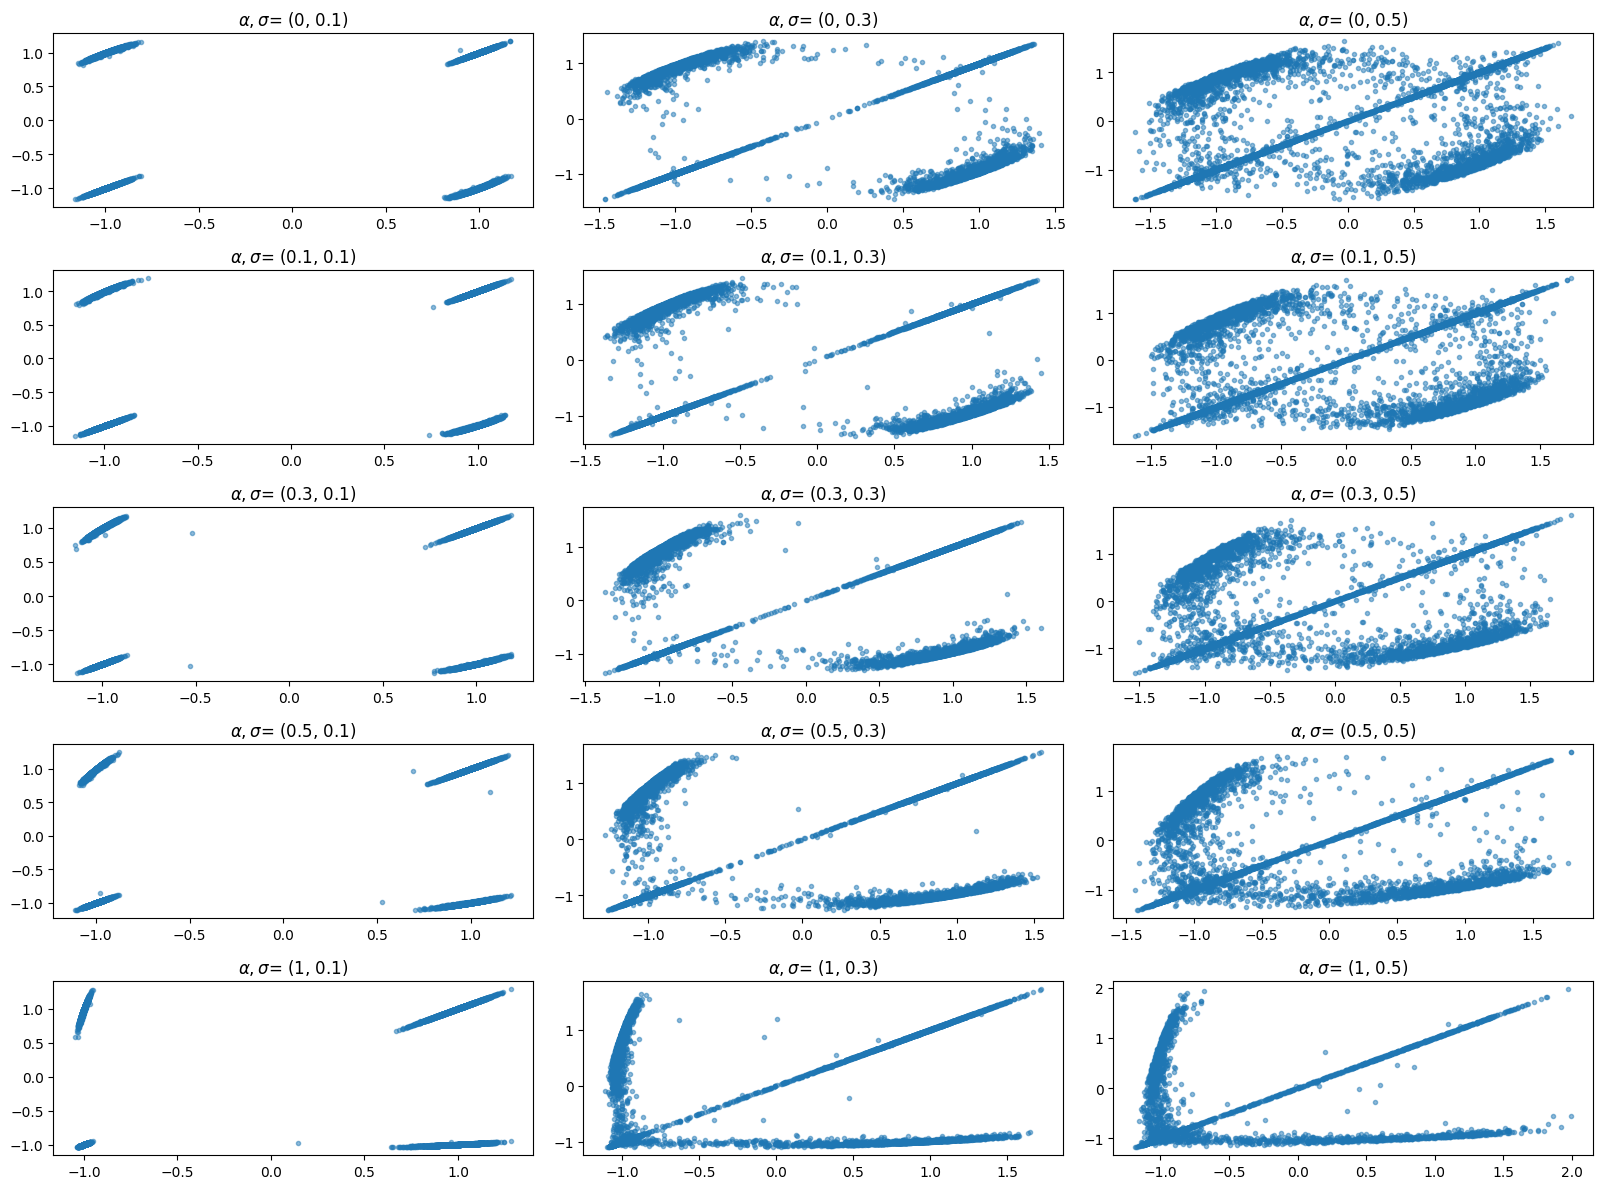

In [116]:
plt.figure(figsize=(16,12))
for i in range(len(alpha_v)):
    alpha = alpha_v[i]

    for j in range(len(sigma_v)):
        k = i*len(sigma_v) + j + 1
        plt.subplot(len(alpha_v), len(sigma_v), k) 
        sigma = sigma_v[j]

        plt.plot(X_T[i][j][-1,0,:],X_T[i][j][-1,1,:],'.',alpha=0.5)
        plt.title(fr"$\alpha,\sigma$= {alpha,sigma}")
plt.tight_layout()
plt.show()

In [117]:
for alpha, X in zip(alpha_v, X_T):
    Y = X[-1]
    print(alpha, np.std(Y, axis=1), np.mean(Y > 0, axis=1))

0 [[6.75035615e-01 1.28405297e+00 3.19621418e-01 ... 4.42375338e-01
  1.64369944e-01 1.33044288e-01]
 [6.64717655e-01 1.27459552e+00 3.11575943e-01 ... 4.33443809e-01
  1.65963189e-01 1.34225926e-01]
 [6.55437761e-01 1.26518277e+00 3.03697707e-01 ... 4.24741116e-01
  1.67575903e-01 1.35433143e-01]
 ...
 [7.67193463e-04 5.36531207e-01 3.43791662e-12 ... 5.56552772e-07
  4.70223177e-07 1.60546398e-05]
 [7.60204310e-04 5.30588322e-01 3.39916983e-12 ... 5.60414615e-07
  4.68648751e-07 1.56619451e-05]
 [7.55210377e-04 5.26425208e-01 3.36375372e-12 ... 5.64828795e-07
  4.67767661e-07 1.52386125e-05]] [[1.  0.5 1.  ... 0.  0.5 1. ]
 [1.  0.5 1.  ... 0.  0.5 1. ]
 [1.  0.5 1.  ... 0.  0.5 1. ]
 ...
 [0.  0.  1.  ... 0.  0.  1. ]
 [0.  0.  1.  ... 0.  0.  1. ]
 [0.  0.  1.  ... 0.  0.  1. ]]
0.1 [[6.75035615e-01 1.28405297e+00 3.19621418e-01 ... 4.42375338e-01
  1.64369944e-01 1.33044288e-01]
 [6.65749308e-01 1.27343202e+00 3.11823250e-01 ... 4.32788395e-01
  1.66296969e-01 1.34848048e-01]
 [6.